# Linear Transformations as Matrices

*Course notes for **Math for Machine Learning**, C1 · W3 · L2 · V02 — "Linear Transformations as Matrices" (DeepLearning.AI).*

The previous video turned a **matrix into a transformation**. This one goes the **other way**: given a linear transformation (we can *see* where it sends the unit square), how do we recover the matrix? The answer is short and powerful:

> **The columns of the matrix are the images of the basis vectors $(1,0)$ and $(0,1)$.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. Recovering the matrix from where the square goes

Suppose an unknown matrix sends the fundamental square (basis) to some parallelogram, and we observe where the corners land:

| point | lands at |
|---|---|
| $(0,0)$ | $(0,0)$ (always) |
| $(1,0)$ | $(3,-1)$ |
| $(0,1)$ | $(2,3)$ |
| $(1,1)$ | $(5,2)$ |

We actually don't need all of it — **only the images of the two basis vectors** $(1,0)$ and $(0,1)$. Those images become the **columns** of the matrix:

$$ (1,0)\mapsto(3,-1), \;\; (0,1)\mapsto(2,3) \quad\Longrightarrow\quad M = \begin{pmatrix} 3 & 2 \\ -1 & 3 \end{pmatrix}. $$

In [2]:
# images of the two basis vectors (read off from the transformation)
img_e1 = np.array([3, -1])   # where (1, 0) lands
img_e2 = np.array([2,  3])   # where (0, 1) lands

# stack them as columns -> the matrix
M = np.column_stack([img_e1, img_e2])
print('M =')
print(M)

M =
[[ 3  2]
 [-1  3]]


In [3]:
# Verify: M reproduces every observed mapping, including (1,1) -> (5,2)
for p, expected in [((1, 0), (3, -1)), ((0, 1), (2, 3)), ((1, 1), (5, 2)), ((0, 0), (0, 0))]:
    got = M @ np.array(p)
    print(f'{p} -> {got}   (expected {expected})')

(1, 0) -> [ 3 -1]   (expected (3, -1))
(0, 1) -> [2 3]   (expected (2, 3))
(1, 1) -> [5 2]   (expected (5, 2))
(0, 0) -> [0 0]   (expected (0, 0))


## 2. Why it works

Any vector is a combination of the basis vectors, $x = x_1(1,0) + x_2(0,1)$. A linear transformation preserves that combination, so

$$ M x = x_1\,(M e_1) + x_2\,(M e_2) = x_1\,(\text{col}_1) + x_2\,(\text{col}_2). $$

Knowing the two column images is enough to know where **every** point goes. Below, the unit square and its image parallelogram — the basis arrows on the right are exactly the columns of $M$.

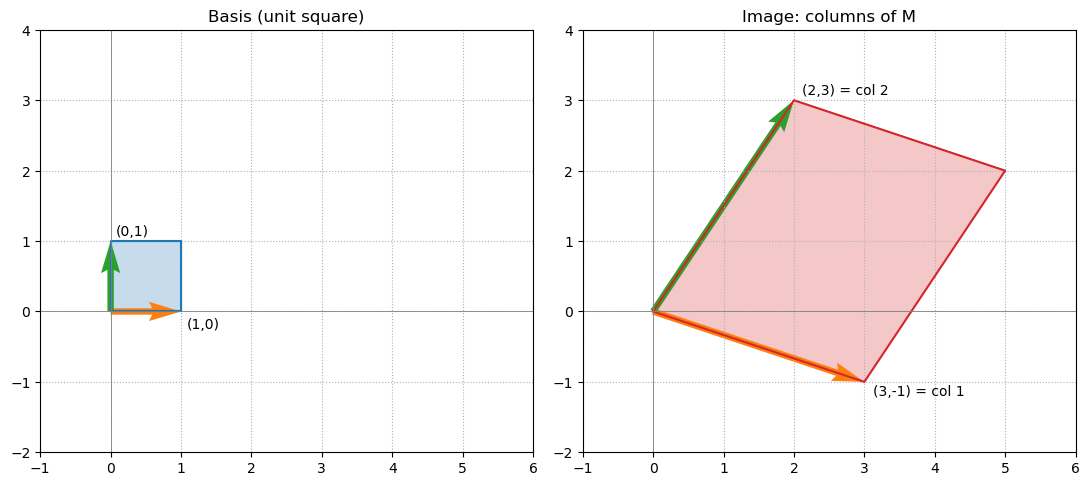

In [4]:
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T
image  = M @ square

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
opts = dict(angles='xy', scale_units='xy', scale=1, width=0.013)

ax = axes[0]
ax.fill(square[0], square[1], color='C0', alpha=0.25); ax.plot(square[0], square[1], color='C0')
ax.quiver(0, 0, 1, 0, color='C1', **opts); ax.quiver(0, 0, 0, 1, color='C2', **opts)
ax.annotate('(1,0)', (1, 0), textcoords='offset points', xytext=(4, -12))
ax.annotate('(0,1)', (0, 1), textcoords='offset points', xytext=(4, 4))
ax.set_title('Basis (unit square)')
ax.set_xlim(-1, 6); ax.set_ylim(-2, 4)

ax = axes[1]
ax.fill(image[0], image[1], color='C3', alpha=0.25); ax.plot(image[0], image[1], color='C3')
ax.quiver(0, 0, *img_e1, color='C1', **opts); ax.quiver(0, 0, *img_e2, color='C2', **opts)
ax.annotate('(3,-1) = col 1', img_e1, textcoords='offset points', xytext=(6, -10))
ax.annotate('(2,3) = col 2', img_e2, textcoords='offset points', xytext=(6, 4))
ax.set_title('Image: columns of M')
ax.set_xlim(-1, 6); ax.set_ylim(-2, 4)

for ax in axes:
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':')
plt.tight_layout(); plt.show()

## Summary

- To turn a **linear transformation into its matrix**, look only at where the two fundamental vectors $(1,0)$ and $(0,1)$ go — those images are the **columns** of the matrix.
- This works because a transformation preserves linear combinations: $Mx = x_1(\text{col}_1) + x_2(\text{col}_2)$, so the two column images determine the whole map.
- Together with the previous video, this shows **matrices and linear transformations are two views of the same object** — you can freely convert between them.
- *(The course follows this with an interactive tool for tweaking a $2\times 2$ matrix and watching it squeeze and rotate the plane.)*